## Testing Vectorizing Common Words in Unique Text Columns

Import after dimensionality reduction part of script

In [272]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

In [273]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   department                         6327 non-null   object
 1   company_profile                    14572 non-null  object
 2   description                        17878 non-null  object
 3   requirements                       15182 non-null  object
 4   benefits                           10660 non-null  object
 5   telecommuting                      17880 non-null  int64 
 6   has_company_logo                   17880 non-null  int64 
 7   has_questions                      17880 non-null  int64 
 8   employment_type                    14409 non-null  object
 9   industry                           12977 non-null  object
 10  function                           11425 non-null  object
 11  fraudulent                         17880 non-null  int64 
 12  Sala

1. vectorize "description" column and get top most frequent words as attributes
2. one-hot encode all other columns
3. stack them so we can train model on vectorized description AND other columns. We can repeat this for other high cardinality string type attributes.

In [274]:
jobs.nunique()

department                             143
company_profile                       1708
description                          14665
requirements                         11898
benefits                              6079
telecommuting                            2
has_company_logo                         2
has_questions                            2
employment_type                          5
industry                                80
function                                37
fraudulent                               2
Salary Given                             2
Grouped_Titles                       10909
Country                                 91
Region                                 325
City                                  2218
special_characters                       2
Bachelor_degree                          2
High school or equivalent                2
Unspecified degree requirement           2
Masters_degree                           2
Associates degree                        2
Certificati

Replicating logic to drop high-cardinality attributes (but plus description)

In [275]:
# X = jobs["description"]

# getting description and company profile attributes to tokenize
unique_values = jobs.nunique() 
selected_columns = unique_values[(unique_values < 145) | (unique_values == 14665) | (unique_values == 1708)].index

# Create a new DataFrame with selected columns
new_df = jobs[selected_columns]
new_df.columns

Index(['department', 'company_profile', 'description', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type', 'industry',
       'function', 'fraudulent', 'Salary Given', 'Country',
       'special_characters', 'Bachelor_degree', 'High school or equivalent',
       'Unspecified degree requirement', 'Masters_degree', 'Associates degree',
       'Certification', 'Some College Coursework Completed', 'Mid-Senior',
       'Entry level', 'Associate', 'Not Application', 'Director',
       'Internship'],
      dtype='object')

Vectorize description column and company profile column using TfidfVectorizer (top 100 words)

In [276]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Replace NaN values in 'description' and 'company_profile' with empty strings
new_df['description'] = new_df['description'].fillna('')
new_df['company_profile'] = new_df['company_profile'].fillna('')

# Initialize TfidfVectorizer
vectorizer_description = TfidfVectorizer(max_features=100, stop_words='english')  # For description
vectorizer_company = TfidfVectorizer(max_features=100, stop_words='english')  # For company_profile

# Fit and transform the 'description' column
vectorizer_description.fit(new_df['description'])
new_df['description_vector'] = list(vectorizer_description.transform(new_df['description']).toarray())

# Fit and transform the 'company_profile' column
vectorizer_company.fit(new_df['company_profile'])
new_df['company_profile_vector'] = list(vectorizer_company.transform(new_df['company_profile']).toarray())

# Drop the original text columns if no longer needed
new_df.drop(columns=['description', 'company_profile'], inplace=True)

# Print the selected features for both columns
print("Description Features:", vectorizer_description.get_feature_names_out())
print("Company Profile Features:", vectorizer_company.get_feature_names_out())

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_41992/3914672788.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['description'] = new_df['description'].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_41992/3914672788.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['company_profile'] = new_df['company_profile'].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_41992/3914672788.py:13: SettingWithCopyWarning: 
A value is trying to be se

Description Features: ['ability' 'able' 'amp' 'apply' 'based' 'best' 'build' 'building'
 'business' 'candidate' 'care' 'client' 'clients' 'communication'
 'company' 'create' 'customer' 'customers' 'data' 'day' 'design' 'develop'
 'development' 'digital' 'duties' 'engineering' 'ensure' 'environment'
 'experience' 'fast' 'great' 'growing' 'growth' 'help' 'high' 'include'
 'including' 'industry' 'information' 'job' 'join' 'key' 'knowledge'
 'lead' 'level' 'like' 'll' 'looking' 'maintain' 'make' 'manage'
 'management' 'manager' 'market' 'marketing' 'media' 'mobile' 'needs'
 'new' 'office' 'opportunity' 'people' 'performance' 'position' 'process'
 'product' 'production' 'products' 'professional' 'project' 'projects'
 'provide' 'quality' 'required' 'requirements' 'responsibilities'
 'responsible' 'role' 'sales' 'service' 'services' 'skills' 'social'
 'software' 'solutions' 'strong' 'support' 'systems' 'team' 'teams'
 'technical' 'technology' 'time' 'training' 'web' 'website' 'work'
 'working

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_41992/3914672788.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['company_profile_vector'] = list(vectorizer_company.transform(new_df['company_profile']).toarray())
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_41992/3914672788.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.drop(columns=['description', 'company_profile'], inplace=True)


Data preparation: storing these tokens (most frequent words) with their respective column name

In [277]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# Step 1: Decompose description_vector and company_profile_vector
description_features = vectorizer_description.get_feature_names_out()
company_profile_features = vectorizer_company.get_feature_names_out()

# Add suffixes to feature names
description_feature_names = [f"description_includes_{feature}" for feature in description_features]
company_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)  # Feature names for categorical features
# Combine all feature names into a single list
all_feature_names = np.concatenate([description_feature_names, company_profile_feature_names, categorical_feature_names])

# Convert description_vector and company_profile_vector to DataFrames
description_df = pd.DataFrame(
    np.vstack(new_df['description_vector'].values), 
    columns=description_feature_names
)
company_profile_df = pd.DataFrame(
    np.vstack(new_df['company_profile_vector'].values), 
    columns=company_profile_feature_names
)

# Concatenate the new DataFrames with the original DataFrame
new_df = pd.concat([new_df.reset_index(drop=True), description_df, company_profile_df], axis=1)

# Drop the original vector columns if no longer needed
new_df.drop(columns=['description_vector', 'company_profile_vector'], inplace=True)

# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

# Combine all features into a single matrix
X = np.hstack([description_df.values, company_profile_df.values, categorical_features])
y = new_df['fraudulent'].values  # Target variable

# Check the shape of the final feature matrix
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (17880, 595)


In [278]:
new_df.columns

Index(['department', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent', 'Salary Given',
       'Country',
       ...
       'companyprof_includes_technical', 'companyprof_includes_technology',
       'companyprof_includes_time', 'companyprof_includes_want',
       'companyprof_includes_way', 'companyprof_includes_web',
       'companyprof_includes_work', 'companyprof_includes_working',
       'companyprof_includes_world', 'companyprof_includes_years'],
      dtype='object', length=224)

Extract description_vector as Numpy array, 
one-hot-encode categorical columns
combine encoded features with description_vector
train classifier on this

In [279]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder


One hot encode all other categorical columns:

In [280]:
'''
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Separate the target column
jobs = new_df
y = jobs['fraudulent'].values
# Select all columns except 'description_vector' and 'fraudulent'
# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

# Step 3: Combine All Features
X = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])

# Check the shape of the final feature matrix
print(X.shape)
'''

"\nfrom sklearn.preprocessing import OneHotEncoder\nimport numpy as np\n\n# Separate the target column\njobs = new_df\ny = jobs['fraudulent'].values\n# Select all columns except 'description_vector' and 'fraudulent'\n# Step 2: One-Hot Encode Categorical Columns\nencoder = OneHotEncoder(sparse_output=False)\ncategorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)\ncategorical_features = encoder.fit_transform(new_df[categorical_columns])\n\n# Step 3: Combine All Features\nX = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])\n\n# Check the shape of the final feature matrix\nprint(X.shape)\n"

In [281]:
'''
# One-hot encode the categorical columns
categorical_features = encoder.fit_transform(jobs[categorical_columns])

# Convert description_vector to a 2D NumPy array
description_vectors = np.vstack(jobs['description_vector'].values)
company_profile_vectors = np.vstack(jobs['company_profile_vector'].values)
X = np.hstack([description_vectors, company_profile_vectors, categorical_features])

print(X.shape)  # Check the shape of the combined feature matrix
X
'''

"\n# One-hot encode the categorical columns\ncategorical_features = encoder.fit_transform(jobs[categorical_columns])\n\n# Convert description_vector to a 2D NumPy array\ndescription_vectors = np.vstack(jobs['description_vector'].values)\ncompany_profile_vectors = np.vstack(jobs['company_profile_vector'].values)\nX = np.hstack([description_vectors, company_profile_vectors, categorical_features])\n\nprint(X.shape)  # Check the shape of the combined feature matrix\nX\n"

In [282]:
# After one-hot encoding:
len(X[0])
# there are 595 attributes!
# 395 attributes from one-hot encoding categorical predictors, and 100 from each of the text features

595

Random forest classifier

In [283]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(all_feature_names[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Accuracy: 0.9807
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.99      0.62      0.77       181

    accuracy                           0.98      3576
   macro avg       0.99      0.81      0.88      3576
weighted avg       0.98      0.98      0.98      3576

Top 10 Most Important Features:
has_company_logo_0: 0.0269
has_company_logo_1: 0.0251
industry_Oil & Energy: 0.0228
description_includes_work: 0.0222
description_includes_time: 0.0203
companyprof_includes_candidates: 0.0182
function_Administrative: 0.0135
description_includes_skills: 0.0120
description_includes_amp: 0.0113
industry_Accounting: 0.0112


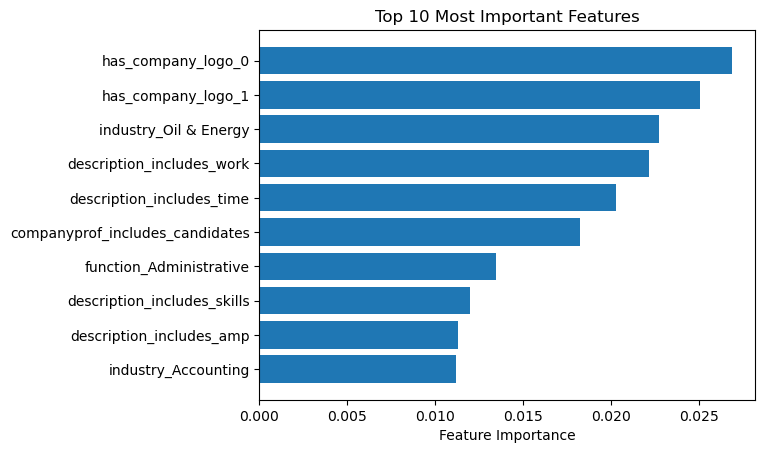

In [284]:
import matplotlib.pyplot as plt

# Plot feature importances
sorted_indices = np.argsort(feature_importances)[::-1]
top_features = sorted_indices[:10]  # Top 10 features
plt.barh(range(10), feature_importances[top_features])
plt.yticks(range(10), [all_feature_names[i] for i in top_features])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

# we expect that feature importance will be low! 

In [285]:
# Smote LR Model
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
smote = SMOTE(sampling_strategy='auto', random_state=42)  # auto balances the classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3395
           1       0.49      0.90      0.63       181

    accuracy                           0.95      3576
   macro avg       0.74      0.92      0.80      3576
weighted avg       0.97      0.95      0.95      3576



Small improvement in metrics from version where all these variables are dropped. May see even better model performance with other variable-length string attributes.

We can repeat this methodology with other unique text columns like company description, requirements, benefits. Can also use digram, bigrams, etc. to get most common phrases